In [49]:
import sys

sys.path.append("..")

import numpy as np
from utils.synthetic_anomalies import *
from sklearn.linear_model import LinearRegression
from hydra import compose, initialize

# from utils.tools import load_models
from scipy.stats import norm
from utils.synthetic_anomalies import (
    add_event_group,
    reverse_event,
    add_outlier_group,
    add_jump,
    simple_noise_event,
    add_seasonal_cycle_increase,
    add_trend_increase,
    linear_pipeline,
)

from scipy.stats import ranksums
from scipy.stats import ttest_ind


import matplotlib.pyplot as plt

import sys

sys.path.append("..")

from utils.data_parsing_tools import (
    load_data_bases,
)

from scipy.stats import entropy


from scipy.stats import ttest_ind


# I need to build the following: 


- Trend increase ✔
- Var increase ✔
- Event Anomaly 
- Outliers (Mostly important to sanity check the other detection schemes) ✔
- Jump anomaly (Every moves up) ✔

Everything here should be variable in intensity to properly evaluate anomaly dection methods.




In [50]:
with initialize(version_base=None, config_path="../forecasting_analysis/conf/"):
    cfg = compose(config_name="config.yaml", return_hydra_config=True)

/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'config.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


In [51]:
cfg.dir = "ps"
ps, exogs = load_data_bases(cfg)

data = ps["Lister"]["asc0"][["720593"]]
data.index.name = "date"

exogs = exogs["Moehne"]
exogs = exogs.rename(columns={"datetime": "date"})

Load cached data
Load cached data


In [52]:
test_case1 = add_trend_increase(
    data,
    increase_strength=5,
    nonlinear_trend=True,
    nl_trend_strength=2,
    increase_start_index=240,
).interpolate()



test_case2 = add_event_group(
    increase_start_index=250,
    df=data,
    event=reverse_event(data, increase_start_index=250, length=500),
).interpolate()
train = test_case1[:200]
test = test_case1[200:]

In [53]:
test_case1.iloc[50:]

,720593
date,
2016-01-29,-3.202040
2016-02-04,-5.465590
2016-02-10,-7.729140
2016-02-16,-7.445700
2016-02-22,-7.162260
...,...
2020-12-03,10.544530
2020-12-09,17.767810
2020-12-15,12.432233


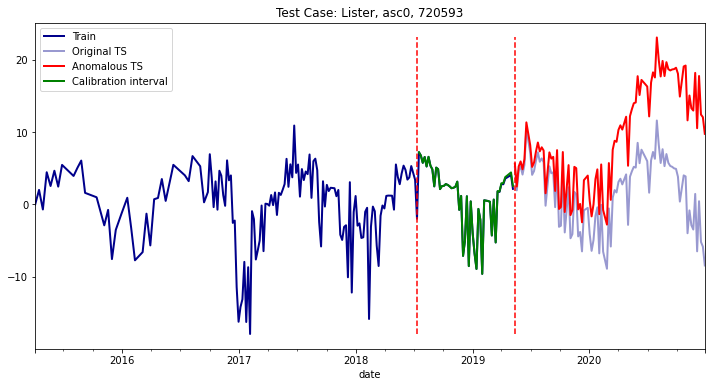

In [54]:
fig, ax = plt.subplots(figsize=(12, 6))
data.rename(columns={"720593": "Train"}).interpolate()[:250].plot(ax=ax,linewidth=2, color="darkblue")
data.rename(columns={"720593": "Original TS"}).interpolate()[250:].plot(ax=ax,linewidth=2, color="darkblue", alpha=0.4)

test.rename(columns={"720593": "Anomalous TS"}).iloc[50:].plot(ax=ax, color="red", linewidth=2)
test.rename(columns={"720593": "Calibration interval"}).iloc[:50].plot(ax=ax, color="green", linewidth=2)

plt.title("Test Case: Lister, asc0, 720593")


plt.vlines(
    x=train.index[-1],
    ymin=test_case1.min().values[0],
    ymax=test_case1.max().values[0],
    color="red",
    linestyle="--",
    label="Train/Test Split",
)

plt.vlines(
    x=test.index[50],
    ymin=test_case1.min().values[0],
    ymax=test_case1.max().values[0],
    color="red",
    linestyle="--",
    label="Train/Test Split",
)

In [61]:
def model(
    train,
    ax,
    past_days=0,
    autoregressive=0,
    cols=["W"],
    plot_bases=True,
    naming="Bad model",
    text_pos=0.8,
    color = "orange"
):
    targetT, temporaryT = linear_pipeline(
        train,
        exogs,
        cols=cols,
        past_days=past_days,
        autoregressive=autoregressive,
        return_temporary=True,
    )
    m, min_max = linear_pipeline(
        train,
        exogs,
        cols=cols,
        past_days=past_days,
        autoregressive=autoregressive,
        return_temporary=False,
    )
    target, temporary = linear_pipeline(
        test,
        exogs,
        cols=cols,
        past_days=past_days,
        autoregressive=autoregressive,
        return_temporary=True,
        min_max=min_max,
    )
    pred = m.predict(temporary)
    predT = m.predict(temporaryT)
    if plot_bases:
        ax[2].hlines(0.05, 0, 50, color="red", linestyle="--", label="p=0.05 threshold")

        targetT.reset_index().plot.scatter(
            x="date", y=targetT.columns[0], ax=ax[0], label="Train", color="violet"
        )
        target[:40].reset_index().plot.scatter(
            x="date",
            y=target.columns[0],
            ax=ax[0],
            label="Normal Test",
            color="blue",
        )

        target[40:].reset_index().plot.scatter(
            x="date",
            y=target.columns[0],
            ax=ax[0],
            label="Anomalous Test",
            color="red",
        )

    pred.plot(ax=ax[0], color=color, linewidth=2)
    predT.plot(ax=ax[0], color=color, linewidth=2)

    train_resids = (predT - targetT.values[:, 0]).abs()
    test_resids = (pred - target.values[:, 0]).abs()

    ax[1].hist(test_resids[:40], label=naming, alpha=0.5, bins=10, color=color)

    # Plot train and test residuals as text
    ax[0].text(
        -1.5,
        text_pos,
        naming
        + f"\nTrain MAE: {train_resids.mean():.3f}\nTest MAE: {test_resids[:40].mean():.3f}",
        transform=ax[1].transAxes,
        fontsize=12,
        verticalalignment="top",
        bbox=dict(boxstyle="round", fc="w", ec="0.5", alpha=0.8),
    )
    stack = []
    stack2 = []
    for x in range(50):
        # shuffle test
        p_value = ranksums(
            test_resids[:40].dropna(), test_resids.dropna()[40 + x : 40 + x + 50]
        ).pvalue
        stack.append(p_value)

        # bins = np.histogram_bin_edges(
        #     np.concatenate(
        #         [test_resids[:40].dropna(), test_resids.dropna()[40 + x : 40 + x + 50]]
        #     ),
        #     bins=10,
        # )
        # hist_p, _ = np.histogram(test_resids[:40].dropna(), bins=bins, density=True)
        # hist_q, _ = np.histogram(
        #     test_resids.dropna()[40 + x : 40 + x + 50], bins=bins, density=True
        # )
        # # Add a small value to avoid division by zero
        # hist_p += 1e-10
        # hist_q += 1e-10
        # stack2.append(entropy(hist_p, hist_q))

    #mean = test_resids[:40].mean()
    #std = test_resids[:40].std()
    #Z = (test_resids[40:] - mean) / std
    # Z.abs().cumsum().plot(ax=ax[1,1], label=naming + "Accumulated Z-Score")

    # Z.abs().plot(ax=ax[1,1], label=naming + "Accumulated Z-Score")
    #print(stack2)
    #ax[2].plot(stack2, label=naming, color=color)

    ax[2].plot(stack, label=naming, color=color)
    ax[2].set_title("Wilcoxon test p-values", fontsize=12)
    ax[0].set_title("Residuals for non-anomalous test data")
    ax[1].set_title("Distribution over absolute residuals \n during normal test window")


/home/stein/anaconda3/envs/dam/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


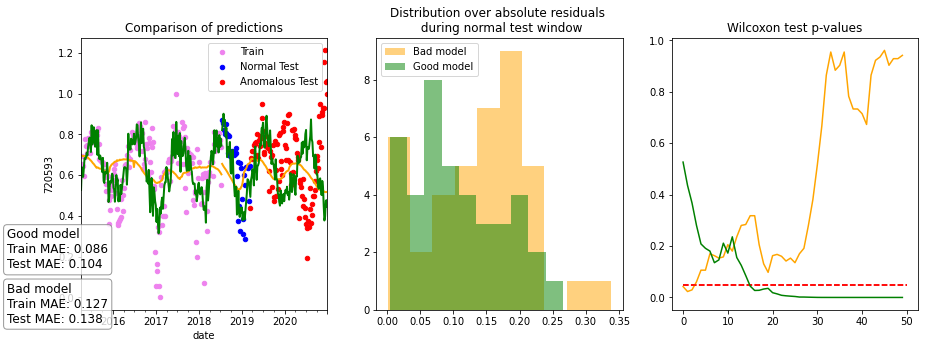

In [737]:
test_case1 = add_seasonal_cycle_increase(
    data,
    increase_start_index=250,
    increase_strength=0.2,
).interpolate()
train = test_case1[:200]
test = test_case1[200:]


# Naive model
fig, ax = plt.subplots(1,3, figsize=(15, 5))

resids = model(
    train, ax, past_days=0, autoregressive=0, naming="Bad model", text_pos=0.1, color="orange"
)

resids2 = model(
    train,
    ax,
    past_days=3,
    autoregressive=0,
    plot_bases=False,
    naming="Good model",
    cols=["W", "T"],
    color="green",
    text_pos=0.3
)

#ax[0].legend()
#ax[0].legend(loc=3)
ax[1].legend()


ax[0].set_title("Comparison of predictions", fontsize=12)
plt.show()

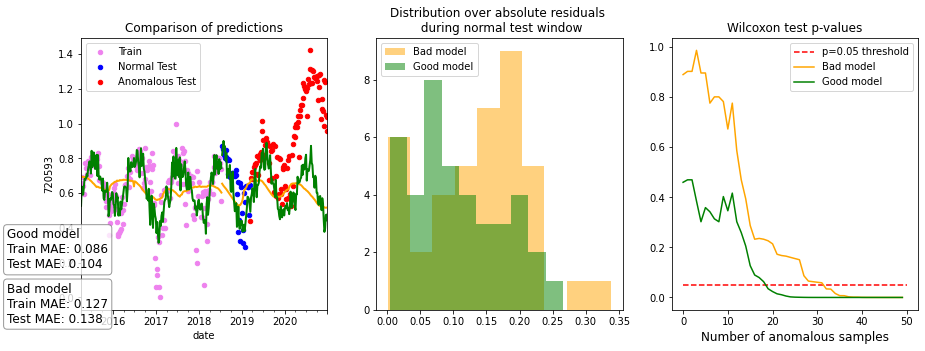

In [65]:
test_case1 = add_trend_increase(
    data,
    increase_strength=5,
    nonlinear_trend=True,
    nl_trend_strength=2,
    increase_start_index=240,
).interpolate()


train = test_case1[:200]
test = test_case1[200:]


# Naive model
fig, ax = plt.subplots(1,3, figsize=(15, 5))

resids = model(
    train, ax, past_days=0, autoregressive=0, naming="Bad model", cols=["W"], text_pos=0.1, color="orange"
)

resids2 = model(
    train,
    ax,
    past_days=3,
    autoregressive=0,
    plot_bases=False,
    naming="Good model",
    cols=["W", "T"],
    color="green",
    text_pos=0.3
)

#ax[0].legend()
#ax[0].legend(loc=3)
ax[1].legend()
ax[2].legend()

ax[2].set_xlabel("Number of anomalous samples", fontsize=12)

ax[0].set_title("Comparison of predictions", fontsize=12)

plt.savefig("anomaly_baseline.png", dpi=200, bbox_inches="tight")

In [1]:
test_case1.plot()


NameError: name 'test_case1' is not defined

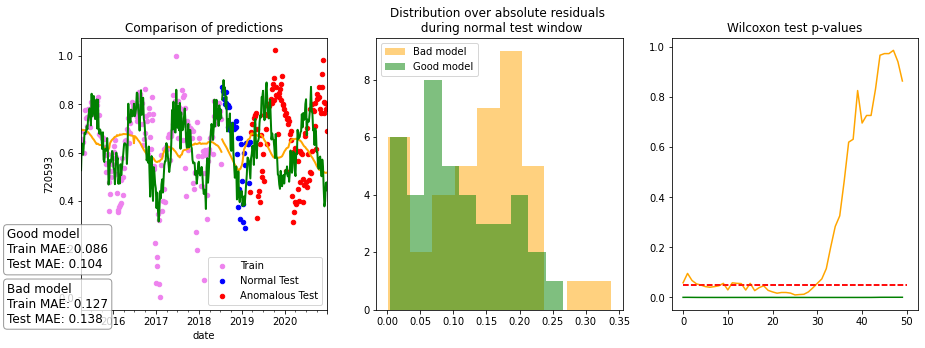

In [739]:
test_case1 = add_event_group(
    increase_start_index=250,
    df=data,
    event=reverse_event(data, increase_start_index=250, length=500),
).interpolate()
train = test_case1[:200]
test = test_case1[200:]


# Naive model
fig, ax = plt.subplots(1,3, figsize=(15, 5))

resids = model(
    train, ax, past_days=0, autoregressive=0, naming="Bad model", text_pos=0.1, color="orange"
)

resids2 = model(
    train,
    ax,
    past_days=3,
    autoregressive=0,
    plot_bases=False,
    naming="Good model",
    cols=["W", "T"],
    color="green",
    text_pos=0.3
)

#ax[0].legend()
#ax[0].legend(loc=3)
ax[1].legend()


ax[0].set_title("Comparison of predictions", fontsize=12)
plt.show()